# San Antonio bicyclist crash analysis

This notebook analyzes TxDOT CRIS records for pedalcyclists killed or suspected seriously injured. It keeps 2026 separate because the export runs only through Sept. 1, 2026.

The person-level filters are `3 - PEDALCYCLIST` and `K - FATAL INJURY` **OR** `A - SUSPECTED SERIOUS INJURY`.

In [2]:
from pathlib import Path
import zipfile
import requests
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
DATA = ROOT / 'data'
RAW = DATA / 'raw'
BOUNDARIES = DATA / 'boundaries'
OUT = ROOT / 'outputs'
BOUNDARIES.mkdir(exist_ok=True)
OUT.mkdir(exist_ok=True)
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)

In [3]:
# Load and filter the CRIS export. The export has 12 metadata rows before the header.
csv_path = RAW / 'myexport_final.csv'
raw = pd.read_csv(csv_path, skiprows=12, low_memory=False)
severity = {'K - FATAL INJURY', 'A - SUSPECTED SERIOUS INJURY'}
target = raw[(raw['Person Type'] == '3 - PEDALCYCLIST') & raw['Person Injury Severity'].isin(severity)].copy()
target['Crash Year'] = pd.to_numeric(target['Crash Year'], errors='coerce').astype('Int64')
target['Latitude_num'] = pd.to_numeric(target['Latitude'], errors='coerce')
target['Longitude_num'] = pd.to_numeric(target['Longitude'], errors='coerce')
target['serious_injury'] = (target['Person Injury Severity'] == 'A - SUSPECTED SERIOUS INJURY').astype(int)
target['death'] = (target['Person Injury Severity'] == 'K - FATAL INJURY').astype(int)
target['affected'] = 1
print('Filtered people:', len(target))
print('Unique crashes:', target['Crash ID'].nunique())
print(target.groupby(['City', 'Crash Year']).agg(people=('affected','sum'), serious_injuries=('serious_injury','sum'), deaths=('death','sum'), crashes=('Crash ID','nunique')).tail(12))

Filtered people: 4743
Unique crashes: 4694
                          people  serious_injuries  deaths  crashes
City          Crash Year                                           
WICHITA FALLS 2023             1                 1       0        1
              2025             2                 2       0        2
              2026             1                 0       1        1
WILLIS        2025             2                 2       0        2
              2026             1                 1       0        1
WIMBERLEY     2016             2                 2       0        2
WOLFE CITY    2024             1                 1       0        1
WYLIE         2019             1                 1       0        1
              2021             2                 2       0        2
              2024             1                 0       1        1
              2026             2                 2       0        2
YORKTOWN      2026             1                 1       0        1


In [4]:
# San Antonio trend: people, not crashes, are the outcome counts.
sa = target[target['City'] == 'SAN ANTONIO']
annual_sa = sa.groupby('Crash Year').agg(people=('affected','sum'), serious_injuries=('serious_injury','sum'), deaths=('death','sum'), crashes=('Crash ID','nunique')).reset_index()
annual_sa.to_csv(OUT / 'san_antonio_annual.csv', index=False)
annual_sa

,Crash Year,people,serious_injuries,deaths,crashes
0,2016,30,25,5,29
1,2017,31,29,2,31
2,2018,26,22,4,26
3,2019,20,15,5,20
4,2020,15,14,1,15
5,2021,15,10,5,15
6,2022,34,25,9,34
7,2023,33,25,8,33
8,2024,40,34,6,40
9,2025,21,15,6,21


In [5]:
# City comparison using average annual population estimates, 2016-2025.
# The population file combines Census 2010-2020 intercensal estimates for 2016-19
# with the Census 2020-2025 estimates for 2020-25.
cities = ['HOUSTON', 'SAN ANTONIO', 'DALLAS', 'AUSTIN', 'FORT WORTH', 'EL PASO']
city_names = {'HOUSTON':'Houston', 'SAN ANTONIO':'San Antonio', 'DALLAS':'Dallas', 'AUSTIN':'Austin', 'FORT WORTH':'Fort Worth', 'EL PASO':'El Paso'}
pop = pd.read_csv(DATA / 'population_estimates.csv')
pop['city_upper'] = pop['city'].str.upper()
avg_pop = pop.groupby('city_upper', as_index=False)['population'].mean().rename(columns={'population':'average_population_2016_2025'})
city = target[(target['City'].isin(cities)) & (target['Crash Year'].between(2016, 2025))].groupby('City').agg(affected_bicyclists=('affected','sum'), serious_injuries=('serious_injury','sum'), deaths=('death','sum'), crashes=('Crash ID','nunique')).reset_index()
city['city'] = city['City'].map(city_names)
city = city.merge(avg_pop, left_on='City', right_on='city_upper', how='left')
city['annual_affected_rate_per_100k'] = city['affected_bicyclists'] / 10 / city['average_population_2016_2025'] * 100000
city['annual_death_rate_per_100k'] = city['deaths'] / 10 / city['average_population_2016_2025'] * 100000
city = city.sort_values('annual_affected_rate_per_100k', ascending=False)
city.to_csv(OUT / 'city_comparison.csv', index=False)
city[['city','average_population_2016_2025','affected_bicyclists','serious_injuries','deaths','annual_affected_rate_per_100k','annual_death_rate_per_100k']]

,city,average_population_2016_2025,affected_bicyclists,serious_injuries,deaths,annual_affected_rate_per_100k,annual_death_rate_per_100k
0,Austin,963853.0,309,275,34,3.205883,0.352751
4,Houston,2324435.2,535,427,108,2.301634,0.464629
1,Dallas,1310431.5,256,227,29,1.953555,0.221301
5,San Antonio,1463515.8,265,214,51,1.810708,0.348476
3,Fort Worth,935884.0,114,101,13,1.218100,0.138906
2,El Paso,679578.3,52,46,6,0.765180,0.088290


## What San Antonio's severe-injury and fatal crashes have in common

This section is descriptive, not causal. Intersection categories are crash-level and remain separate: `INTERSECTION`, `INTERSECTION RELATED`, `DRIVEWAY ACCESS` and `NON INTERSECTION` are not collapsed into one category. Helmet status is person-level. CRIS contributing factors can overlap and are police-recorded codes, not an independent determination of fault.

In [6]:
sa_people = target[(target['City'] == 'SAN ANTONIO') & target['Crash Year'].between(2016, 2025)].copy()
sa_crashes = sa_people.drop_duplicates('Crash ID').copy()
commonality_rows = []

intersection_categories = sa_crashes['Intersection Related'].value_counts(dropna=False)
for category, count in intersection_categories.items():
    commonality_rows.append({'topic':'Intersection context', 'category':str(category), 'unit':'crashes', 'count':int(count), 'denominator':int(len(sa_crashes)), 'share':count/len(sa_crashes)})

helmet = sa_people['Person Helmet'].value_counts(dropna=False)
for category, count in helmet.items():
    commonality_rows.append({'topic':'Helmet status', 'category':str(category), 'unit':'bicyclists', 'count':int(count), 'denominator':int(len(sa_people)), 'share':count/len(sa_people)})

factor_cols = ['Contributing Factor 1','Contributing Factor 2','Contributing Factor 3','Possible Contributing Factor 1','Possible Contributing Factor 2']
factor_text = sa_crashes[factor_cols].fillna('').astype(str).agg(' | '.join, axis=1)
factor_groups = {'Failed to yield':'FAILED TO YIELD', 'Driver inattention':'DRIVER INATTENTION', 'Disregard stop sign/light':'DISREGARD STOP', 'Speed-related code':'SPEED', 'Alcohol/intoxication code':'ALCOHOL|INTOXICATED', 'Drug code':'DRUG'}
for label, pattern in factor_groups.items():
    count = factor_text.str.contains(pattern, case=False, regex=True).sum()
    commonality_rows.append({'topic':'Contributing-factor code', 'category':label, 'unit':'crashes', 'count':int(count), 'denominator':int(len(sa_crashes)), 'share':count/len(sa_crashes)})

commonalities = pd.DataFrame(commonality_rows)
commonalities.to_csv(OUT / 'commonalities.csv', index=False)
commonalities

,topic,category,unit,count,denominator,share
0,Intersection context,NON INTERSECTION,crashes,127,264,0.481061
1,Intersection context,INTERSECTION,crashes,73,264,0.276515
2,Intersection context,INTERSECTION RELATED,crashes,49,264,0.185606
3,Intersection context,DRIVEWAY ACCESS,crashes,15,264,0.056818
4,Helmet status,1 - NOT WORN,bicyclists,218,265,0.822642
5,Helmet status,99 - UNKNOWN IF WORN,bicyclists,27,265,0.101887
6,Helmet status,"2 - WORN, DAMAGED",bicyclists,13,265,0.049057
7,Helmet status,"3 - WORN, NOT DAMAGED",bicyclists,4,265,0.015094
8,Helmet status,"4 - WORN, UNK DAMAGE",bicyclists,3,265,0.011321
9,Contributing-factor code,Failed to yield,crashes,36,264,0.136364


### Coverage warning

The uploaded export does not provide usable hit-and-run values, and it does not include a reliable narrative-level determination of fault. Those should not be presented as findings from this file.

In [7]:
# Download boundary files only when needed.
tract_zip = BOUNDARIES / 'tl_2020_48_tract.zip'
tract_url = 'https://www2.census.gov/geo/tiger/TIGER2020/TRACT/tl_2020_48_tract.zip'
if not tract_zip.exists():
    tract_zip.write_bytes(requests.get(tract_url, timeout=120).content)
tract_dir = BOUNDARIES / 'tracts'
if not tract_dir.exists():
    tract_dir.mkdir()
    with zipfile.ZipFile(tract_zip) as z:
        z.extractall(tract_dir)
tracts = gpd.read_file(tract_dir / 'tl_2020_48_tract.shp', columns=['GEOID','NAME','COUNTYFP','geometry'])
tracts = tracts[tracts['COUNTYFP'] == '029'].to_crs(4326)

# One crash row with person-level outcome totals.
crashes = target[target['City'] == 'SAN ANTONIO'].groupby('Crash ID').agg(year=('Crash Year','first'), latitude=('Latitude_num','first'), longitude=('Longitude_num','first'), serious_injuries=('serious_injury','sum'), deaths=('death','sum')).reset_index()
crashes = crashes.dropna(subset=['latitude','longitude'])
points = gpd.GeoDataFrame(crashes, geometry=gpd.points_from_xy(crashes['longitude'], crashes['latitude']), crs=4326)
tract_join = gpd.sjoin(points, tracts[['GEOID','NAME','geometry']], how='left', predicate='within')
tract_counts = tract_join[tract_join['year'].between(2016, 2025)].groupby(['GEOID','NAME'], as_index=False).agg(serious_injuries=('serious_injuries','sum'), deaths=('deaths','sum'), crashes=('Crash ID','nunique'))
tract_counts['affected_bicyclists'] = tract_counts['serious_injuries'] + tract_counts['deaths']
tract_counts = tract_counts.sort_values(['affected_bicyclists','deaths'], ascending=False)
tract_counts.to_csv(OUT / 'census_tract_hotspots.csv', index=False)
tract_counts.head(15)

,GEOID,NAME,serious_injuries,deaths,crashes,affected_bicyclists
0,48029110100,1101,8,0,8,8
133,48029191900,1919,4,3,7,7
4,48029111100,1111,6,1,7,7
10,48029120902,1209.02,6,1,7,7
79,48029171000,1710,4,2,6,6
81,48029171200,1712,3,2,5,5
13,48029121203,1212.03,4,1,5,5
43,48029150100,1501,5,0,5,5
50,48029151100,1511,5,0,5,5
19,48029121403,1214.03,3,1,4,4


In [8]:
# Rough directional quadrants using the downtown reference point as the dividing lines.
lat0, lon0 = 29.4241, -98.4936
points['quadrant'] = np.where(points['latitude'] >= lat0, 'N', 'S') + np.where(points['longitude'] < lon0, 'W', 'E')
quadrants = points[points['year'].between(2016, 2025)].groupby('quadrant', as_index=False).agg(serious_injuries=('serious_injuries','sum'), deaths=('deaths','sum'), crashes=('Crash ID','nunique'))
quadrants['affected_bicyclists'] = quadrants['serious_injuries'] + quadrants['deaths']
quadrants['share_of_geocoded_affected'] = quadrants['affected_bicyclists'] / quadrants['affected_bicyclists'].sum()
quadrants = quadrants.set_index('quadrant').reindex(['NW','NE','SW','SE']).reset_index()
quadrants.to_csv(OUT / 'quadrants.csv', index=False)
quadrants

,quadrant,serious_injuries,deaths,crashes,affected_bicyclists,share_of_geocoded_affected
0,NW,72,19,91,91,0.362550
1,NE,55,12,67,67,0.266932
2,SW,49,12,60,61,0.243028
3,SE,24,8,32,32,0.127490


In [9]:
# City Council districts from the official City of San Antonio ArcGIS service.
# Requesting outSR=4326 avoids the export endpoint's asynchronous download behavior.
council_url = 'https://services.arcgis.com/g1fRTDLeMgspWrYp/arcgis/rest/services/CouncilDistricts/FeatureServer/2/query?where=1%3D1&outFields=District&returnGeometry=true&outSR=4326&f=geojson'
council_file = BOUNDARIES / 'council_districts.geojson'
if not council_file.exists():
    council_file.write_bytes(requests.get(council_url, timeout=120).content)
council = gpd.read_file(council_file).to_crs(4326)
district_join = gpd.sjoin(points, council[['District','geometry']], how='left', predicate='within')
districts = district_join[district_join['year'].between(2016, 2025)].groupby('District', as_index=False).agg(serious_injuries=('serious_injuries','sum'), deaths=('deaths','sum'), crashes=('Crash ID','nunique'))
districts['affected_bicyclists'] = districts['serious_injuries'] + districts['deaths']
districts = districts.sort_values(['affected_bicyclists','deaths'], ascending=False)
districts.to_csv(OUT / 'council_districts.csv', index=False)
districts

,District,serious_injuries,deaths,crashes,affected_bicyclists
4,5,36,12,48,48
0,1,34,6,40,40
1,2,30,8,38,38
2,3,29,6,35,35
6,7,19,3,22,22
9,10,16,3,19,19
3,4,13,4,17,17
5,6,10,6,15,16
7,8,10,2,12,12
8,9,3,1,4,4


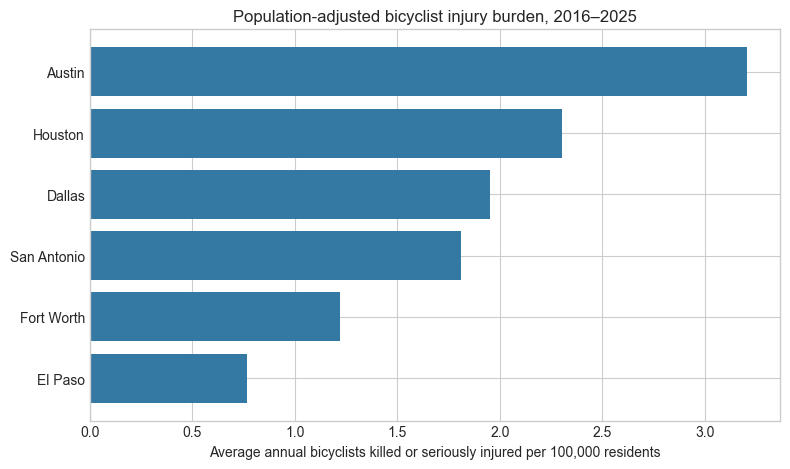

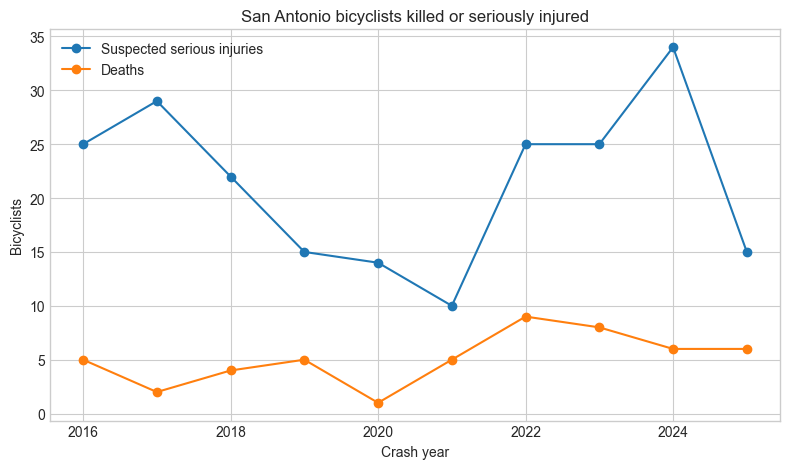

In [10]:
# Editor-ready charts.
fig, ax = plt.subplots(figsize=(8, 4.8))
plot_city = city.sort_values('annual_affected_rate_per_100k')
ax.barh(plot_city['city'], plot_city['annual_affected_rate_per_100k'], color='#3478a4')
ax.set_xlabel('Average annual bicyclists killed or seriously injured per 100,000 residents')
ax.set_title('Population-adjusted bicyclist injury burden, 2016–2025')
fig.tight_layout()
fig.savefig(OUT / 'city_comparison_rate.png', dpi=200)
plt.show()

trend = annual_sa[annual_sa['Crash Year'] <= 2025]
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(trend['Crash Year'], trend['serious_injuries'], marker='o', label='Suspected serious injuries')
ax.plot(trend['Crash Year'], trend['deaths'], marker='o', label='Deaths')
ax.set_xlabel('Crash year')
ax.set_ylabel('Bicyclists')
ax.set_title('San Antonio bicyclists killed or seriously injured')
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(OUT / 'san_antonio_annual_trend.png', dpi=200)
plt.show()